## Fine-tunning pre-trained ViT 

In [2]:
!pip install -q transformers datasets evaluate accelerate -U

In [4]:
from torchvision.datasets import ImageFolder
from torchvision.transforms import ToTensor
import numpy as np
import random
import cv2
from sklearn.metrics import confusion_matrix
from matplotlib import cm
import matplotlib.pyplot as plt
from datasets import DatasetDict, Dataset
import evaluate
import torch
import PIL
from transformers import ViTFeatureExtractor, ViTImageProcessor, ViTForImageClassification, TrainingArguments, Trainer, pipeline, DefaultDataCollator

In [6]:
import numpy as np
import torch
import cv2
import torch.nn as nn
from transformers import ViTModel, ViTConfig
from torchvision import transforms
from torch.optim import Adam
from torch.utils.data import DataLoader
from tqdm import tqdm
from sklearn import metrics as pred_metrics
import os
import pickle

#Pretrained model checkpoint
model_checkpoint = 'google/vit-base-patch16-224-in21k'
feature_extractor = ViTImageProcessor.from_pretrained(model_checkpoint)

# Gold Data

## Load data

In [97]:
def load_data_to_cpu(file_pattern, num_files):
    data_list = []
    for idx in range(num_files):
        with open(file_pattern.format(idx), "rb") as file:
            data = pickle.load(file)
        data_list.append(data)
    data_array = np.asarray(data_list)
    return data_array

In [122]:
with open("../data/train_imgs_tf.pkl", "rb") as f:
    train_imgs_tf = pickle.load(f).numpy()
with open("../data/df_tr.pkl", "rb") as f:
    df_tr = pickle.load(f)

with open("../data/val_imgs_tf.pkl", "rb") as f:
    val_imgs_tf = pickle.load(f).numpy()
with open("../data/df_val.pkl", "rb") as f:
    df_val = pickle.load(f)   

with open("../data/test_imgs_tf.pkl", "rb") as f:
    test_imgs_tf = pickle.load(f).numpy()
with open("../data/df_test.pkl", "rb") as f:
    df_test = pickle.load(f)

In [12]:
q_train_images = load_data_to_cpu("../quantum/train/train_{}.pkl", len(train_imgs_tf))
print(q_train_images.shape)

q_val_images = load_data_to_cpu("../quantum/validation/val_{}.pkl", len(val_imgs_tf))
print(q_val_images.shape)

q_test_images = load_data_to_cpu("../quantum/test/test_{}.pkl", len(test_imgs_tf))
print(q_test_images.shape)

(2784, 63, 63, 24)
(800, 63, 63, 24)
(416, 63, 63, 24)


In [123]:
# Crea un DatasetDict y agrega los conjuntos de datos mezclados
data_dict = DatasetDict()

train_data = Dataset.from_dict({
    'image': [sample for sample in train_imgs_tf],
    'labels': [sample for sample in df_tr["class"]]
})
data_dict['train'] = train_data

valid_data = Dataset.from_dict({
    'image': [sample for sample in val_imgs_tf],
    'labels': [sample for sample in df_val["class"]]
})
data_dict['valid'] = valid_data

test_data = Dataset.from_dict({
    'image': [sample for sample in test_imgs_tf],
    'labels': [sample for sample in df_test["class"]]
})
data_dict['test'] = test_data

print(data_dict)

DatasetDict({
    train: Dataset({
        features: ['image', 'labels'],
        num_rows: 2784
    })
    valid: Dataset({
        features: ['image', 'labels'],
        num_rows: 800
    })
    test: Dataset({
        features: ['image', 'labels'],
        num_rows: 416
    })
})


In [ ]:
# Transformar las imágenes
def transform(example_batch):
    inputs = feature_extractor(np.array(example_batch['image']), return_tensors='pt')
    # No olvides incluir las etiquetas
    inputs['labels'] = example_batch['labels']
    return inputs

In [128]:
train_dataset = data_dict['train'].with_transform(transform)
test_dataset = data_dict['test'].with_transform(transform)
val_dataset = data_dict['valid'].with_transform(transform)

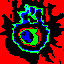

In [81]:
import PIL.Image


PIL.Image.fromarray(train_imgs_tf[0].astype("uint8").numpy())

In [114]:
print(data_dict['train'][0])

{'image': [[[-1.133437349530435, 0.23407945262041596, 0.4927988476219283], [-1.133437349530435, 0.23407945262041596, 0.4927988476219283], [-1.133437349530435, 0.23407945262041596, 0.4927988476219283], [-1.182717234292628, 0.22175948142986773, 0.4927988476219283], [-1.2935969750075618, 0.18479956785822313, 0.4681589052408319], [-1.3428768597697547, 0.1724795966676749, 0.4681589052408319], [-1.2073571766737246, 0.20943951023931953, 0.48047887643138015], [-1.059517522387146, 0.25871939500151236, 0.5051188188124766], [-0.9979176664344048, 0.28335933738260877, 0.5174387900030247], [-1.0225576088155013, 0.2710393661920606, 0.5174387900030247], [-1.0718374935776942, 0.25871939500151236, 0.5051188188124766], [-1.0718374935776942, 0.25871939500151236, 0.5051188188124766], [-1.0841574647682424, 0.25871939500151236, 0.5051188188124766], [-1.0471975511965976, 0.25871939500151236, 0.5051188188124766], [-0.9979176664344048, 0.28335933738260877, 0.5174387900030247], [-0.9609577528627603, 0.3203192509

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


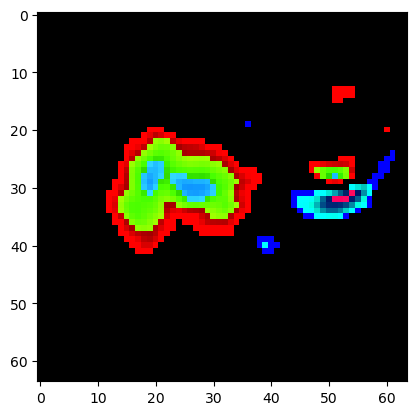

In [115]:
plt.imshow(np.transpose(data_dict['test'][0]['image'],(0,1,2)))

In [129]:
plt.imshow(np.transpose(test_dataset[0]['pixel_values'],(1,2,0)))

ValueError: Invalid image type. Expected either PIL.Image.Image, numpy.ndarray, torch.Tensor, tf.Tensor or jax.ndarray, but got <class 'list'>.

In [37]:
labels = ['C','MCA','MCD','MU']
label2id, id2label = dict(), dict()
for i, label in enumerate(labels):
    label2id[label] = str(i)
    id2label[str(i)] = label

label2id

{'C': '0', 'MCA': '1', 'MCD': '2', 'MU': '3'}

## Model

In [38]:
feature_extractor

ViTImageProcessor {
  "do_convert_rgb": null,
  "do_normalize": true,
  "do_rescale": true,
  "do_resize": true,
  "image_mean": [
    0.5,
    0.5,
    0.5
  ],
  "image_processor_type": "ViTImageProcessor",
  "image_std": [
    0.5,
    0.5,
    0.5
  ],
  "resample": 2,
  "rescale_factor": 0.00392156862745098,
  "size": {
    "height": 224,
    "width": 224
  }
}

In [39]:
def collate_fn(batch):
    return {'pixel_values': torch.stack([x['pixel_values'] for x in batch]),
            'labels': torch.tensor([x['labels'] for x in batch])}

In [40]:
metric = evaluate.combine(["f1","accuracy"])
def compute_metrics(p):
    return metric.compute(predictions=np.argmax(p.predictions, axis=1), references=p.label_ids)

In [41]:
model = ViTForImageClassification.from_pretrained(model_checkpoint,
                                                  num_labels=len(labels),
                                                  id2label=id2label,
                                                  label2id=label2id)

Some weights of ViTForImageClassification were not initialized from the model checkpoint at google/vit-base-patch16-224-in21k and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [42]:
training_args = TrainingArguments(output_dir="./ViTresults/",
                                  remove_unused_columns=False,
                                  evaluation_strategy="epoch",
                                  save_strategy="epoch",
                                  learning_rate=5e-5,
                                  per_device_train_batch_size=2,
                                  per_device_eval_batch_size=2,
                                  gradient_accumulation_steps=4,
                                  num_train_epochs=10,
                                  warmup_ratio=0.1,
                                  load_best_model_at_end=True,
                                  metric_for_best_model="f1",
                                  push_to_hub=False)

c:\Users\mateo\anaconda3\envs\tensor_gpu\lib\site-packages\transformers\training_args.py:1594: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(


In [ ]:
trainer = Trainer(model=model,
                  args=training_args,
                  data_collator=collate_fn,
                  compute_metrics=compute_metrics,
                  train_dataset=train_dataset,
                  eval_dataset=val_dataset,
                  tokenizer=feature_extractor)

C:\Users\mateo\AppData\Local\Temp\ipykernel_23924\2861638963.py:1: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(model=model,


In [52]:
#Sin entrenar
metrics = trainer.evaluate(test_dataset)
trainer.log_metrics("eval", metrics)
trainer.save_metrics("eval", metrics)

AttributeError: 'list' object has no attribute 'read'

## Training Model

In [33]:
#ORIGINAL
train_results = trainer.train()
trainer.save_model("./ViTresults")
trainer.log_metrics("train", train_results.metrics)
trainer.save_metrics("train", train_results.metrics)
trainer.save_state()
torch.save(model.state_dict(),"./ViTresults/ViT.pth")

Epoch,Training Loss,Validation Loss,F1,Accuracy
0,No log,0.150017,0.959288,0.960494
1,No log,0.160112,0.953459,0.954321
2,0.033300,0.173147,0.956843,0.956790
4,0.002700,0.193325,0.958128,0.958025
5,0.002700,0.200089,0.956843,0.956790
6,0.002700,0.207261,0.959410,0.959259
8,0.001600,0.214716,0.958231,0.958025
9,0.001300,0.216949,0.957055,0.956790


***** train metrics *****
  epoch                    =         9.96
  total_flos               = 1202569364GF
  train_loss               =       0.0097
  train_runtime            =   0:14:30.04
  train_samples_per_second =       18.447
  train_steps_per_second   =        2.299


In [34]:
metrics = trainer.evaluate(test_dataset)
trainer.log_metrics("eval", metrics)
trainer.save_metrics("eval", metrics)

***** eval metrics *****
  epoch                   =       9.96
  eval_accuracy           =     0.8972
  eval_f1                 =     0.8706
  eval_loss               =     0.3889
  eval_runtime            = 0:00:02.16
  eval_samples_per_second =     49.453
  eval_steps_per_second   =     24.957


In [35]:
outputs = trainer.predict(test_dataset)
y_pred = outputs.predictions.argmax(1)
true_labels = data_dict['test']['labels']
print(pred_metrics.classification_report(true_labels, y_pred, digits = 3))

              precision    recall  f1-score   support

           0      0.952     0.881     0.915        67
           1      0.822     0.925     0.871        40

    accuracy                          0.897       107
   macro avg      0.887     0.903     0.893       107
weighted avg      0.903     0.897     0.898       107



## Results

In [15]:
model = ViTForImageClassification.from_pretrained(model_checkpoint,
                                                  num_labels=len(labels),
                                                  id2label=id2label,
                                                  label2id=label2id)
model.load_state_dict(torch.load("./ViTresults/ViT_Orig.pth"))
model.eval() 

Some weights of ViTForImageClassification were not initialized from the model checkpoint at google/vit-base-patch16-224-in21k and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


ViTForImageClassification(
  (vit): ViTModel(
    (embeddings): ViTEmbeddings(
      (patch_embeddings): ViTPatchEmbeddings(
        (projection): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
      )
      (dropout): Dropout(p=0.0, inplace=False)
    )
    (encoder): ViTEncoder(
      (layer): ModuleList(
        (0-11): 12 x ViTLayer(
          (attention): ViTAttention(
            (attention): ViTSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.0, inplace=False)
            )
            (output): ViTSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.0, inplace=False)
            )
          )
          (intermediate): ViTIntermediate(
            (dense): Linear(in_features=7

In [16]:
images = data_dict['test']['image']
true_labels = data_dict['test']['labels']
predicted=[]

for ruta in tqdm(images):
    img=cv2.imread(ruta)
    inputs = feature_extractor([PIL.Image.open(ruta).convert("RGB")], return_tensors='pt')['pixel_values']
    with torch.no_grad():
        preds = model(inputs, output_attentions=True)
        predicted.append(preds)

print(preds.keys())

100%|███████████████████████████████████████████████████████████████████████| 107/107 [01:52<00:00,  1.05s/it]

odict_keys(['logits', 'attentions'])


In [82]:
my_preds=[pred.logits.argmax().cpu().numpy().tolist() for pred in predicted]

Predicción:  [0, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0] 
Valor Esperado: [0, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 1, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0] 
***************
Métricas: 
              precision    recall  f1-score   support

           0      0.952     0.881     0.915        67
           1      0.822     0.925     0.871        40

    accuracy                          0.897       107
   macro avg      0.887     0.903     0.893       107
weighted avg      0.903   

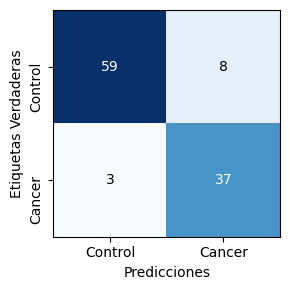

In [83]:
print('Predicción: ', my_preds,end=' ')
print()
print('Valor Esperado:', true_labels, end=' ')
print()
print('*'*15)
print("Métricas: ")
matc=confusion_matrix(true_labels,
                      my_preds)
# Crear una figura y un eje
fig, ax = plt.subplots(figsize=(3,3))
# Mostrar la matriz de confusión con etiquetas personalizadas
ax.imshow(matc, interpolation='nearest',cmap=cm.Blues)

# Configurar etiquetas en los ejes
ax.set_xticks(np.arange(len(labels)))
ax.set_yticks(np.arange(len(labels)))
ax.set_xticklabels(labels)
ax.set_yticklabels(labels,rotation=90)

ax.set_xlabel('Predicciones')
ax.set_ylabel('Etiquetas Verdaderas')
# Agregar etiquetas a cada celda
thresh = matc.max() / 2.0
for i in range(matc.shape[0]):
    for j in range(matc.shape[1]):
        ax.text(j, i, format(matc[i, j], 'd'),
                ha="center", va="center",
                color="white" if matc[i, j] > thresh else "black")
plt.tight_layout()

from sklearn import metrics as pred_metrics
print(pred_metrics.classification_report(true_labels, my_preds, digits = 3))

In [84]:
for pred in predicted:
    print(pred.attentions[-1])
    print(pred.attentions[-1].shape[1])
    break

tensor([[[[2.0957e-05, 2.6577e-03, 2.3884e-03,  ..., 1.3581e-03,
           2.0741e-03, 2.0494e-03],
          [6.7662e-04, 1.9278e-03, 2.0696e-03,  ..., 1.3859e-03,
           2.7992e-03, 3.9373e-03],
          [4.8753e-04, 2.1841e-03, 1.9162e-03,  ..., 1.7302e-03,
           2.8967e-03, 3.5312e-03],
          ...,
          [9.5504e-04, 3.2668e-03, 2.3983e-03,  ..., 1.6038e-03,
           3.0736e-03, 7.4561e-03],
          [6.8376e-04, 2.5603e-03, 1.8909e-03,  ..., 1.7027e-03,
           2.6786e-03, 5.7786e-03],
          [9.0443e-04, 3.0347e-03, 2.5717e-03,  ..., 1.7189e-03,
           2.8089e-03, 4.6523e-03]],

         [[7.7336e-06, 6.4297e-04, 6.1146e-04,  ..., 3.7002e-04,
           5.1363e-04, 3.1620e-04],
          [4.6266e-04, 9.3263e-04, 8.1079e-04,  ..., 4.9384e-04,
           6.3839e-04, 7.4294e-04],
          [2.8230e-04, 1.0787e-03, 8.6222e-04,  ..., 4.5839e-04,
           5.7795e-04, 5.4695e-04],
          ...,
          [5.7863e-04, 1.2495e-03, 1.0189e-03,  ..., 6.8234

In [85]:
predicted[-1]

ImageClassifierOutput(loss=None, logits=tensor([[ 3.2157, -3.2027]]), hidden_states=None, attentions=(tensor([[[[7.1962e-01, 4.0143e-03, 2.8825e-03,  ..., 2.0881e-03,
           2.3696e-03, 4.5647e-03],
          [1.8752e-02, 9.7642e-01, 1.3738e-04,  ..., 4.9709e-06,
           1.6324e-05, 3.4039e-05],
          [3.9137e-01, 7.9756e-03, 4.8158e-01,  ..., 2.2294e-04,
           2.6657e-04, 1.5734e-03],
          ...,
          [4.7836e-01, 2.1752e-04, 2.4565e-04,  ..., 3.3554e-01,
           5.1453e-03, 1.4876e-02],
          [3.2587e-02, 3.6577e-05, 1.3123e-05,  ..., 2.6350e-04,
           9.5508e-01, 3.0939e-03],
          [9.8584e-02, 1.0794e-04, 1.6395e-04,  ..., 1.3631e-03,
           5.1510e-03, 8.6045e-01]],

         [[7.8417e-01, 1.6000e-03, 1.8206e-03,  ..., 1.3142e-03,
           8.7401e-04, 1.3814e-03],
          [3.0232e-01, 1.0807e-01, 4.8798e-03,  ..., 4.9018e-03,
           2.3268e-03, 3.8355e-03],
          [3.2248e-01, 5.1964e-03, 2.0174e-02,  ..., 3.8913e-03,
        

### Attention

Para empezar vamos a tomar sólo un par de outputs, y visualizar tanto imagen como su mapa de atención.

In [14]:
def visualize_attention(output, preprocessed_image):
    attentions = output.attentions[-1] # we are only interested in the attention maps of the last layer
    nh = attentions.shape[1] # number of head
    
    # we keep only the output patch attention
    attentions = attentions[0, :, 0, 1:].reshape(nh, -1)
    print(attentions.shape)

    threshold = 0.6
    w_featmap = preprocessed_image.shape[-2] // model.config.patch_size
    h_featmap = preprocessed_image.shape[-1] // model.config.patch_size
    
    # we keep only a certain percentage of the mass
    val, idx = torch.sort(attentions)
    val /= torch.sum(val, dim=1, keepdim=True)
    cumval = torch.cumsum(val, dim=1)
    th_attn = cumval > (1 - threshold)
    idx2 = torch.argsort(idx)
    for head in range(nh):
        th_attn[head] = th_attn[head][idx2[head]]
    th_attn = th_attn.reshape(nh, w_featmap, h_featmap).float()
    # interpolate
    th_attn = nn.functional.interpolate(th_attn.unsqueeze(0), scale_factor=model.config.patch_size, mode="nearest")[0].cpu().numpy()
    
    attentions = attentions.reshape(nh, w_featmap, h_featmap)
    attentions = nn.functional.interpolate(attentions.unsqueeze(0), scale_factor=model.config.patch_size, mode="nearest")[0].cpu()
    attentions = attentions.detach().numpy()
    
    # show attentions heatmaps
    print(attentions[0].shape)
    for j in range(nh):
        plt.figure()
        plt.imshow(attentions[j])
    return

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


Ground Truth:  1 . Prediction:  1
torch.Size([12, 196])
(224, 224)


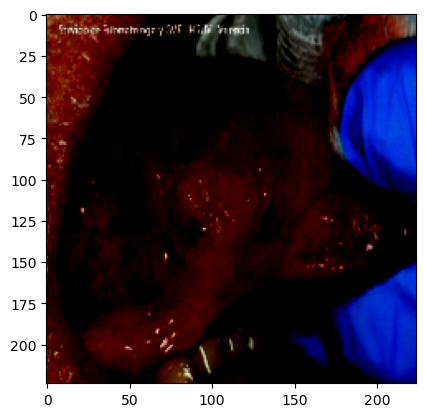

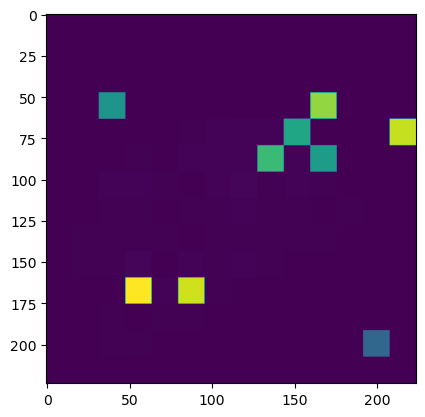

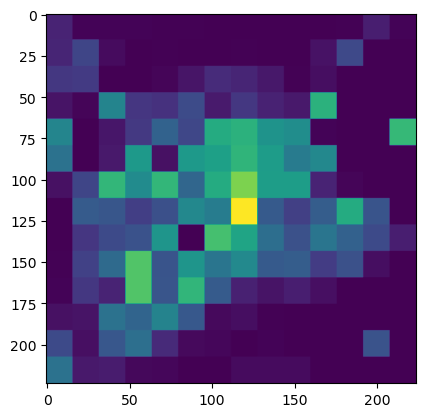

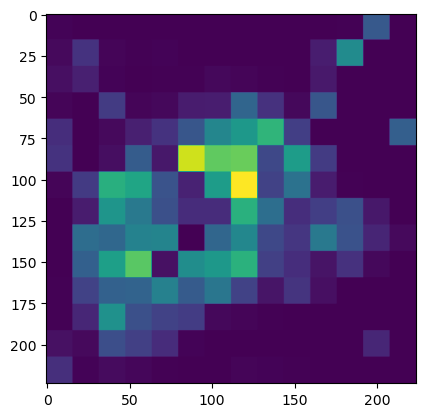

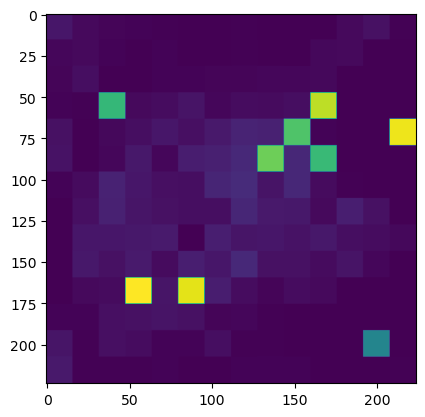

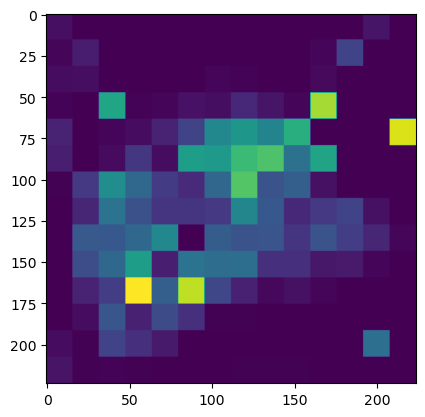

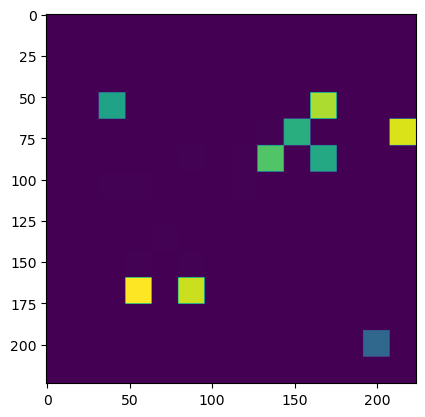

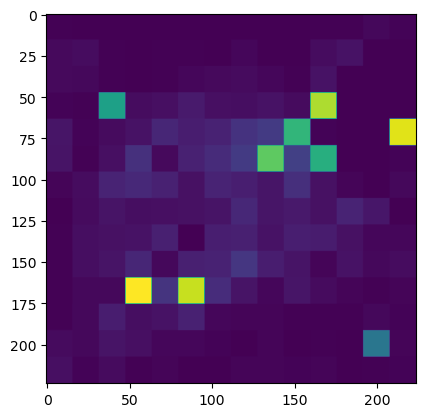

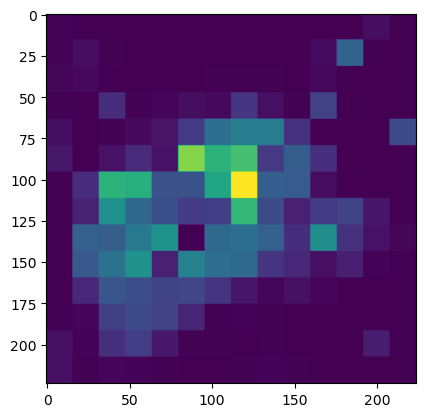

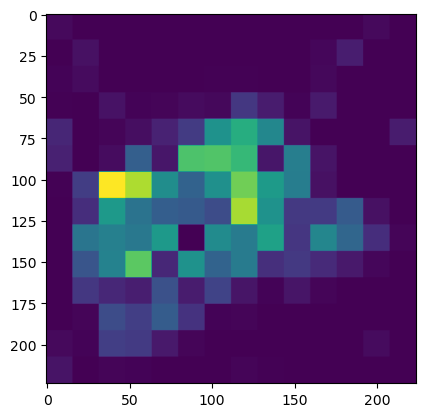

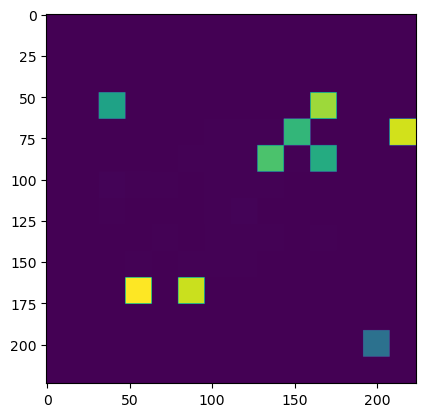

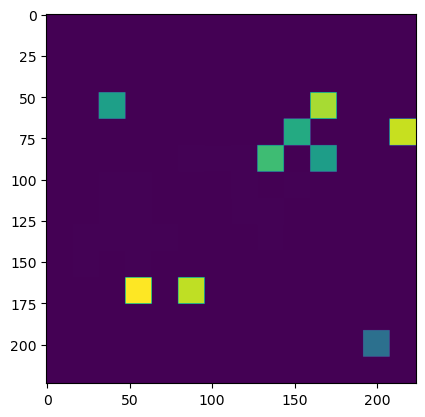

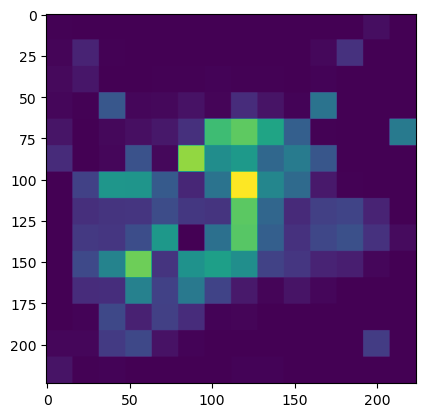

In [134]:
images = data_dict['test']['image'][1]
true_labels = data_dict['test']['labels'][1]

inputs = feature_extractor([PIL.Image.open(images).convert("RGB")], return_tensors='pt')['pixel_values']
with torch.no_grad():
    pred = model(inputs, output_attentions=True,interpolate_pos_encoding=True)
    plt.imshow(np.transpose(np.squeeze(inputs),(1,2,0)))
    value = pred.logits.argmax().cpu().numpy().tolist()
    print('Ground Truth: ',true_labels, '. Prediction: ',value)
    visualize_attention(pred,inputs)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


Ground Truth:  1 . Prediction:  0
torch.Size([12, 196])


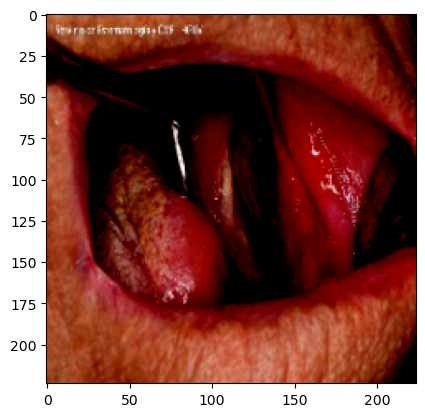

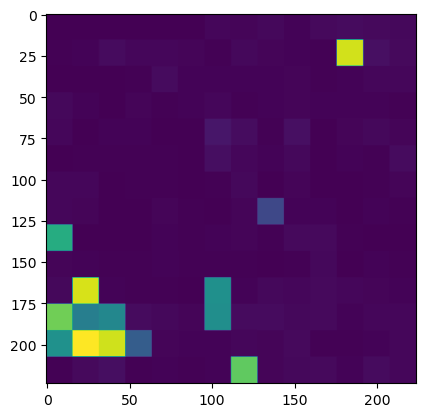

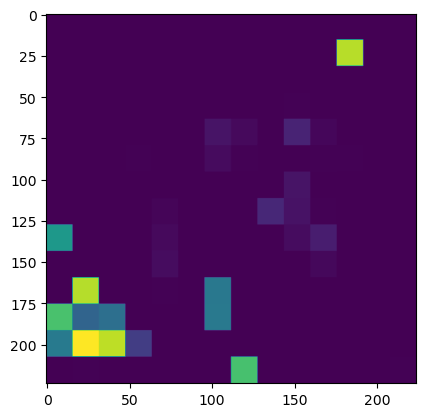

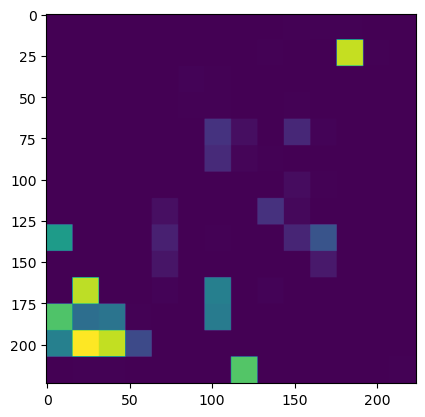

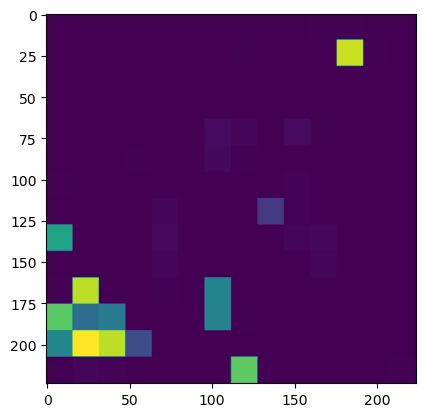

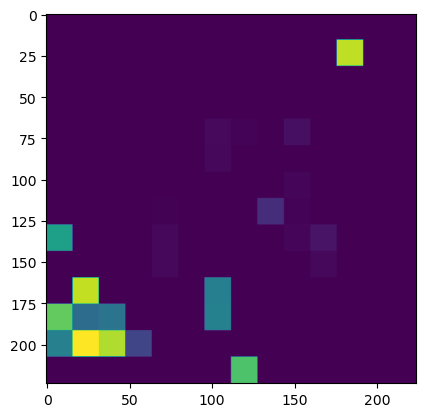

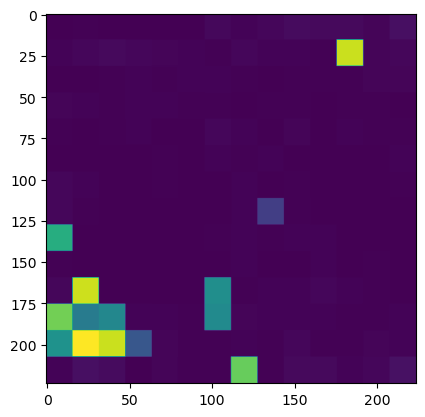

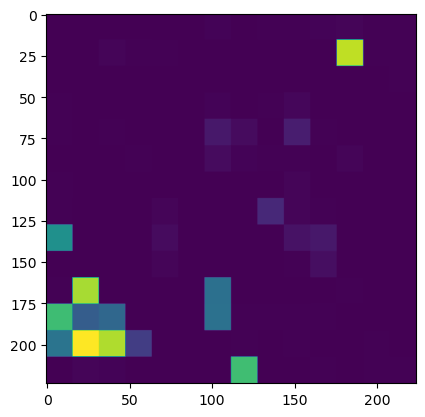

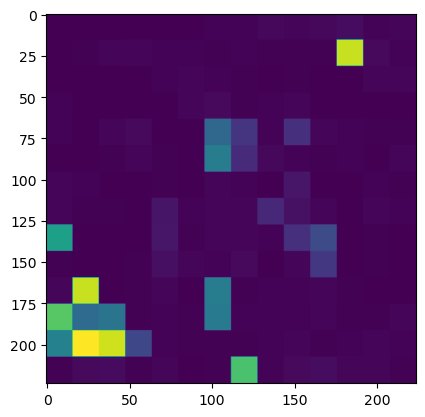

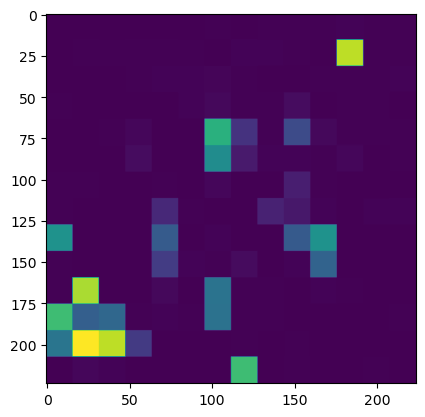

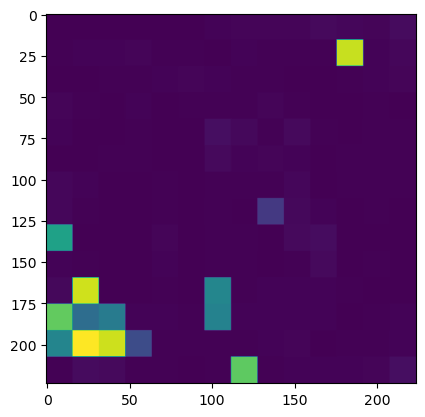

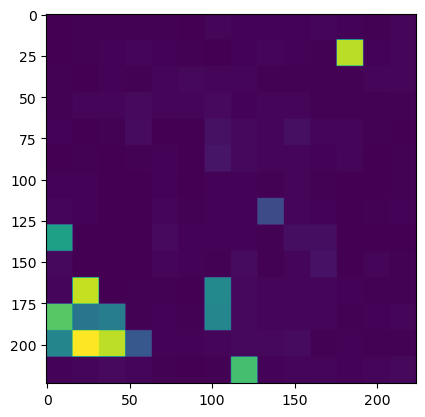

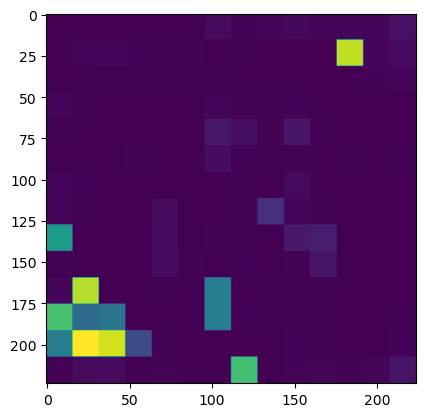

In [103]:
images = data_dict['test']['image'][46]
true_labels = data_dict['test']['labels'][46]

inputs = feature_extractor([PIL.Image.open(images).convert("RGB")], return_tensors='pt')['pixel_values']
with torch.no_grad():
    pred = model(inputs, output_attentions=True,interpolate_pos_encoding=True)
    plt.imshow(np.transpose(np.squeeze(inputs),(1,2,0)))
    value = pred.logits.argmax().cpu().numpy().tolist()
    print('Ground Truth: ',true_labels, '. Prediction: ',value)
    visualize_attention(pred,inputs)

### Save Attention maps

In [119]:
try:
    os.makedirs('./ViT_Attention_Maps')
except OSError as e:
    if e.errno != errno.EEXIST:
        raise

In [18]:
def save_attention(output,image,dir):
    attentions = output.attentions[-1] # we are only interested in the attention maps of the last layer
    nh = attentions.shape[1] # number of head
    
    # we keep only the output patch attention
    attentions = attentions[0, :, 0, 1:].reshape(nh, -1)

    threshold = 0.6
    w_featmap = image.shape[-2] // model.config.patch_size
    h_featmap = image.shape[-1] // model.config.patch_size
    
    # we keep only a certain percentage of the mass
    val, idx = torch.sort(attentions)
    val /= torch.sum(val, dim=1, keepdim=True)
    cumval = torch.cumsum(val, dim=1)
    th_attn = cumval > (1 - threshold)
    idx2 = torch.argsort(idx)
    for head in range(nh):
        th_attn[head] = th_attn[head][idx2[head]]
    th_attn = th_attn.reshape(nh, w_featmap, h_featmap).float()
    # interpolate
    th_attn = nn.functional.interpolate(th_attn.unsqueeze(0), scale_factor=model.config.patch_size, mode="nearest")[0].cpu().numpy()
    
    attentions = attentions.reshape(nh, w_featmap, h_featmap)
    attentions = nn.functional.interpolate(attentions.unsqueeze(0), scale_factor=model.config.patch_size, mode="nearest")[0].cpu()
    attentions = attentions.detach().numpy()
    
    # show attentions heatmaps
    for j in range(nh):
        plt.imsave(fname=dir+"_attn-head_"+str(j)+".jpg", arr=attentions[j],format='jpg')
    return

In [140]:
data['image'][i].split('/')[-1].split('.')[0]

'00052'

In [126]:
sets=['test','valid','train']
from tqdm.notebook import trange, tqdm
import errno

for s in sets:
    data=data_dict[s]

    try:
        os.makedirs('./ViT_Attention_Maps/'+s)
        os.makedirs('./ViT_Attention_Maps/'+s+'/Cáncer')
        os.makedirs('./ViT_Attention_Maps/'+s+'/Control')
    except OSError as e:
        if e.errno != errno.EEXIST:
            raise
    
    for i in trange(len(data),desc="Procesando conjunto "+s):
        image = data['image'][i]
        name = data['image'][i].split('/')[-1].split('.')[0]
    
        if 'C' in name:
            dir = './ViT_Attention_Maps/'+s+'/Cáncer/'+name
        else:
            dir = './ViT_Attention_Maps/'+s+'/Control/'+name
            
        input = feature_extractor([PIL.Image.open(image).convert("RGB")], return_tensors='pt')['pixel_values']
        with torch.no_grad():
            pred = model(input, output_attentions=True,interpolate_pos_encoding=True)
            save_attention(pred,input,dir)

Procesando conjunto test:   0%|          | 0/107 [00:00<?, ?it/s]

Procesando conjunto valid:   0%|          | 0/810 [00:00<?, ?it/s]

Procesando conjunto train:   0%|          | 0/1605 [00:00<?, ?it/s]

In [135]:
try:
    os.makedirs('./ViT_Procesed')
except OSError as e:
    if e.errno != errno.EEXIST:
        raise

In [154]:
sets=['test','valid','train']
from tqdm.notebook import trange, tqdm
import errno
from PIL import Image

for s in sets:
    data=data_dict[s]

    try:
        os.makedirs('./ViT_Procesed/'+s)
        os.makedirs('./ViT_Procesed/'+s+'/Cáncer')
        os.makedirs('./ViT_Procesed/'+s+'/Control')
    except OSError as e:
        if e.errno != errno.EEXIST:
            raise
    
    for i in trange(len(data),desc="Procesando conjunto "+s):
        image = data['image'][i]
        name = data['image'][i].split('/')[-1].split('.')[0]
    
        if 'C' in name:
            dir = './ViT_Procesed/'+s+'/Cáncer/'+name
        else:
            dir = './ViT_Procesed/'+s+'/Control/'+name
            
        input = feature_extractor([PIL.Image.open(image).convert("RGB")], return_tensors='pt')['pixel_values']
        input_np = (input.squeeze() - input.min()) / (input.max() - input.min())

        # Guardar la imagen
        plt.imsave(dir + '.jpg', np.transpose(input_np.numpy(), (1, 2, 0)))

Procesando conjunto test:   0%|          | 0/107 [00:00<?, ?it/s]

Procesando conjunto valid:   0%|          | 0/810 [00:00<?, ?it/s]

Procesando conjunto train:   0%|          | 0/1605 [00:00<?, ?it/s]

In [4]:
#detecciones
new_ruta_dtrain='./data'+TYPE+'/Gold_Standard/dtrain'
new_ruta_dtest='./data'+TYPE+'/Gold_Standard/dtest'
new_ruta_dvalid='./data'+TYPE+'/Gold_Standard/dvalid'

In [7]:
# DETECCIÓN
random.seed(123)
# Transformación para convertir las imágenes a tensores
transform = ToTensor()
dtrain_dataset = ImageFolder(new_ruta_dtrain, transform=transform)
dtest_dataset = ImageFolder(new_ruta_dtest, transform=transform)
dvalid_dataset = ImageFolder(new_ruta_dvalid, transform=transform)

# Obtén las imágenes y etiquetas como listas
dtrain_samples = dtrain_dataset.samples
dtest_samples = dtest_dataset.samples
dvalid_samples = dvalid_dataset.samples

# Mezcla aleatoriamente los índices
random1_permutation = np.random.permutation(len(dtrain_samples))
dtrain_samples = [dtrain_samples[i] for i in random1_permutation]

random2_permutation = np.random.permutation(len(dtest_samples))
dtest_samples = [dtest_samples[i] for i in random2_permutation]

random3_permutation = np.random.permutation(len(dvalid_samples))
dvalid_samples = [dvalid_samples[i] for i in random3_permutation]
# Crea un DatasetDict y agrega los conjuntos de datos mezclados
Ddata_dict = DatasetDict()

dtrain_data = Dataset.from_dict({
    'image': [sample[0] for sample in dtrain_samples],
    'labels': [sample[1] for sample in dtrain_samples]
})
Ddata_dict['train'] = dtrain_data

dvalid_data = Dataset.from_dict({
    'image': [sample[0] for sample in dvalid_samples],
    'labels': [sample[1] for sample in dvalid_samples]
})
Ddata_dict['valid'] = dvalid_data

dtest_data = Dataset.from_dict({
    'image': [sample[0] for sample in dtest_samples],
    'labels': [sample[1] for sample in dtest_samples]
})
Ddata_dict['test'] = dtest_data

print(Ddata_dict)

DatasetDict({
    train: Dataset({
        features: ['image', 'labels'],
        num_rows: 1605
    })
    valid: Dataset({
        features: ['image', 'labels'],
        num_rows: 810
    })
    test: Dataset({
        features: ['image', 'labels'],
        num_rows: 107
    })
})


In [8]:
# Transformar las imágenes
def transform(example_batch):
    inputs = feature_extractor([PIL.Image.open(image_path).convert("RGB") for image_path in example_batch['image']], return_tensors='pt')
    # No olvides incluir las etiquetas
    inputs['labels'] = example_batch['labels']
    return inputs

In [9]:
labels = ['Control','Cancer']
label2id, id2label = dict(), dict()
for i, label in enumerate(labels):
    label2id[label] = str(i)
    id2label[str(i)] = label

label2id

{'Control': '0', 'Cancer': '1'}

In [10]:
def collate_fn(batch):
    return {'pixel_values': torch.stack([x['pixel_values'] for x in batch]),
            'labels': torch.tensor([x['labels'] for x in batch])}

In [11]:
metric = evaluate.combine(["f1","accuracy"])
def compute_metrics(p):
    return metric.compute(predictions=np.argmax(p.predictions, axis=1), references=p.label_ids)

In [12]:
model = ViTForImageClassification.from_pretrained(model_checkpoint,
                                                  num_labels=len(labels),
                                                  id2label=id2label,
                                                  label2id=label2id)
model.load_state_dict(torch.load("./ViTresults/detection_Balanced/DViT.pth"))
model.eval() 

Some weights of ViTForImageClassification were not initialized from the model checkpoint at google/vit-base-patch16-224-in21k and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


ViTForImageClassification(
  (vit): ViTModel(
    (embeddings): ViTEmbeddings(
      (patch_embeddings): ViTPatchEmbeddings(
        (projection): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
      )
      (dropout): Dropout(p=0.0, inplace=False)
    )
    (encoder): ViTEncoder(
      (layer): ModuleList(
        (0-11): 12 x ViTLayer(
          (attention): ViTAttention(
            (attention): ViTSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.0, inplace=False)
            )
            (output): ViTSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.0, inplace=False)
            )
          )
          (intermediate): ViTIntermediate(
            (dense): Linear(in_features=7

In [19]:
sets=['dtest','dvalid','dtrain']
from tqdm.notebook import trange, tqdm
import errno
import time

for s in sets:
    data=Ddata_dict[s[1:]]

    try:
        os.makedirs('./data_Balanced/ViT_Attention_Maps/'+s)
        os.makedirs('./data_Balanced/ViT_Attention_Maps/'+s+'/Cáncer')
        os.makedirs('./data_Balanced/ViT_Attention_Maps/'+s+'/Control')
    except OSError as e:
        if e.errno != errno.EEXIST:
            raise
    
    for i in trange(len(data),desc="Procesando conjunto "+s):
        image = data['image'][i]
        name = data['image'][i].split('/')[-1].split('.')[0]
    
        if 'C' in name:
            dir = './data_Balanced/ViT_Attention_Maps/'+s+'/Cáncer/'+name
        else:
            dir = './data_Balanced/ViT_Attention_Maps/'+s+'/Control/'+name
            
        input = feature_extractor([PIL.Image.open(image).convert("RGB")], return_tensors='pt')['pixel_values']
        with torch.no_grad():
            pred = model(input, output_attentions=True,interpolate_pos_encoding=True)
            save_attention(pred,input,dir)

Procesando conjunto dtest:   0%|          | 0/107 [00:00<?, ?it/s]

KeyboardInterrupt: 